# Age and Gender Distortion - Romain Gazon (8230028)

In a [recent paper in Nature](https://www.nature.com/articles/s41586-025-09581-z), Douglas Guilbeault, Solène Delecourt & Bhargav Srinivasa Desikan investigated how age and gender are jointly distorted across internet content and algorithms. Their research showed that despite no systematic age differences between women and men in the real workforce, women are consistently represented as younger than men — a bias that is most pronounced in high-status, high-earning occupations, amplified by mainstream algorithms and AI, with measurable effects on people's beliefs, hiring preferences, and automated resume evaluations.

In this assignment, we attempt to replicate parts of their work using the datasets available on Douglas Guilbeault's [Google Drive](https://drive.google.com/drive/folders/1-4cy2gYDDRZ8tnZ6ZXES3jcwxNiNucG3).

## Imports

Following standard practice, and for the convenience of the grader, all imports are placed at the beginning in the cell below.

In [1]:
#standard library
import warnings
from pathlib import Path

#core data
import numpy as np
import pandas as pd

#statistics & modelling
import pingouin as pg
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import levene, ttest_1samp, ttest_ind

#visualisation
import altair as alt
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FixedLocator
from plotnine import *
from plotnine.exceptions import PlotnineWarning

### Data Preprocessing: Correlation between Age and Gender and Relationship between Age and Gender

This section covers the preprocessing steps for the data used in the first two parts of the assignment: `Correlation between Age and Gender` and `Relationship between Age and Gender`.

In [2]:
base_path = Path("data")

gpt2_df = pd.read_csv(base_path / "GPT2-large-dimensions.csv")
gpt2_df.head(3)

,Social.Category,Source,gender.main,gender_norm.main,gender.ext,gender_norm.ext,gender.red,gender_norm.red,age.main,age_norm.main,age.ext,age_norm.ext,age.red,age_norm.red
0,abandoned infant,GPT2,-0.197087,0.540877,0.001662,0.527162,-0.108243,0.561858,-0.070237,0.357426,-0.004732,0.319985,-0.055446,0.419423
1,abandoned person,GPT2,-0.199134,0.535577,0.001236,0.523567,-0.110507,0.554830,-0.065570,0.382294,-0.001178,0.343708,-0.048989,0.477159
2,abiogenist,GPT2,-0.231156,0.452671,0.004317,0.549545,-0.151075,0.428889,-0.097012,0.214761,-0.026444,0.175097,-0.063784,0.344863


We drop the `Source` column, which, as seen below, contains only a single value and is therefore uninformative. We then rename the remaining columns to match the variable names used in the assignment sheet's visualizations and snake_case conventions.

In [3]:
gpt2_df['Source'].unique()

array(['GPT2'], dtype=object)

In [4]:
gpt2_df.drop(columns='Source', inplace=True)

columns = ['social_category', 'gender_score', 'gender_norm_main', 'gender_ext', 'gender_norm_ext', 
            'gender_red', 'gender_norm_red', 'age_score', 'age_norm_main', 'age_ext', 
            'age_norm_ext', 'age_red', 'age_norm_red']

gpt2_df.columns = columns

## Correlation Between Age and Gender

In this section we analyze the associations between age and gender in [GPT-2 Large](https://en.wikipedia.org/wiki/GPT-2), the largest and oldest open model available from OpenAI. The associations are calculated by capturing how the internal representation of texts by GPT-2 Large are mapped to age and gender dimensions. In simpler terms, GPT-2 Large was given sentence pairs like *"He is a doctor"* vs *"She is a doctor"* and the cosine distances between word embeddings were used to place each social category on a gender dimension and an age dimension. To quantify this relationship, we calculate the Pearson correlation between `gender_norm_main` and `age_norm_main`, which represent the gender association from 0 (female) to 1 (male) and  the age association from 0 (young) to 1 (old) respectively. 

In [5]:
pg.corr(gpt2_df['gender_norm_main'], gpt2_df['age_norm_main'])

,n,r,CI95,p_val,BF10,power
pearson,3495,0.872559,"[0.86, 0.88]",0.0,inf,1.0


The above results show that for the sample of $n=3495$ social categories from Wordnet, there is a strong
positive linear correlation of $r=0.87$ between gender and age associations. This is supported by a $95\%$
confidence interval of $[0.86, 0.88]$, indicating a precise estimate, and $p<.001$, which is well below the
conventional significance threshold of $α=0.05$, confirming that the correlation is not due to chance. This
means that social categories perceived as more male tend to also be perceived as older.  

In order to confirm the robustness of the results to alternative methods for extracting age and gender
associations, we create all pairwise correlations between the age and gender groups and put them on heatmaps
shown below. We create each one by:

* computing its correlation matrix.
* visualizing it with a custom red colormap, scaled to the minimum observed correlation (`vmin`). The anchor
  points are defined by calculating the percentage difference between values relative to the full observed
  range (e.g. for age, the range is 0.58 to 1.00, so a value of 0.88 sits at 69% of that range and is
  assigned the middle anchor point accordingly).
* Formatting to 2 decimal places and separating cells with white lines for readability.

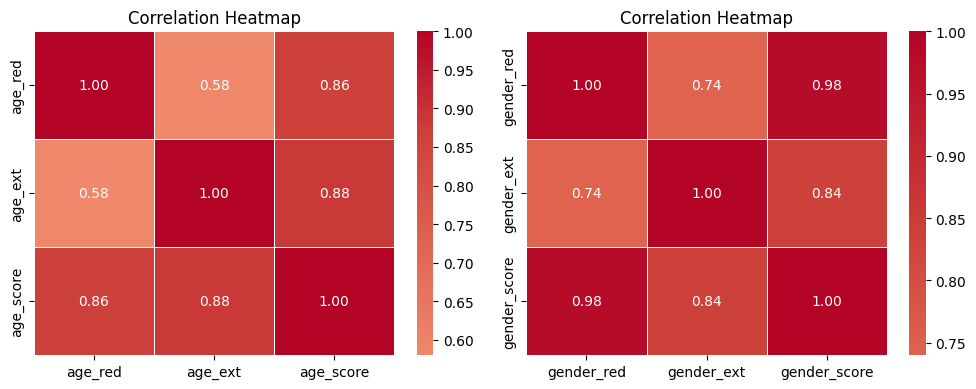

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
heatmap_age_data = gpt2_df[['age_red', 'age_ext', 'age_score']].corr()
colors_hmap_1 = [(0, '#ef886b'), (0.69, '#cc403a'), (1.00, '#b40426')]
cmap_age = LinearSegmentedColormap.from_list('my_cmap', colors_hmap_1)
sns.heatmap(heatmap_age_data, annot=True, fmt='.2f', cmap=cmap_age, linecolor='white',
            linewidths=0.5,  vmin=0.58, ax=axes[0])
axes[0].set_title('Correlation Heatmap')

heatmap_gender_data = gpt2_df[['gender_red', 'gender_ext', 'gender_score']].corr()
colors_hmap_2 = [(0, '#df634e'), (0.38, '#cc403a'), (1.00, '#b40426')]
cmap_gender = LinearSegmentedColormap.from_list('my_cmap', colors_hmap_2)
sns.heatmap(heatmap_gender_data, annot=True, fmt='.2f', cmap=cmap_gender, linecolor='white',
            linewidths=0.5, vmin=0.74, ax=axes[1])
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

The two heatmaps show that the three versions of age and gender are consistent with one another. For age, correlations range from $r=0.58$ to $r=0.88$, while for gender they range from $r=0.74$ to $r=0.98$, suggesting that the gender dimension is more stable across model versions than the age dimension. However, all correlations are considered at minimum `very large` in social sciences according to [Cohen's conventions](https://en.wikipedia.org/wiki/Effect_size#Interpretation) as expanded by Sawilowsky.

## Relationship between Age and Gender

To assess the relationship between age and gender we run a regression between the normalized age and gender
measures.

In [7]:
age_gender_mod = smf.ols("age_norm_main ~ gender_norm_main", data=gpt2_df)
age_gender_res = age_gender_mod.fit()
age_gender_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          age_norm_main   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                 1.114e+04
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:48:24   Log-Likelihood:                 5425.6
No. Observations:                3495   AIC:                        -1.085e+04
Df Residuals:                    3493   BIC:                        -1.083e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.0211      0.003     -6.510      0.000      -0.027      -0.015
gender_norm_main     0.7450      0.007    105.565      0.000       0.731       0.759
==============================================================================
Omnibus:                      829.901   Durbin-Watson:                   1.255
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4643.267
Skew:                           1.012   Prob(JB):                         0.00
Kurtosis:                       8.271   Cond. No.                         9.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The results of the model indicate that gender explains $R^2 = 0.761$ (76.1%) of the variance in age associations across social categories.

* The coefficient of `gender_norm_main` ($\beta=0.745$, $p<.001$, 95% CI $[0.731, 0.759]$) indicates that for every 1-unit increase in perceived gender from female to male, the age association increases by 0.745 units, confirming a strong and statistically significant positive relationship.
* The intercept of $-0.021$ shows that a fully female-associated category is predicted to have a slightly negative age association, meaning it is perceived as very young.
* The model's F-statistic ($F = 11,140$, $p < .001$) confirms the overall significance of the model.

However, it should be noted that the residuals are not normally distributed, as indicated by the significant Omnibus and Jarque–Bera tests, along with positive skewness ($1.012$) and high kurtosis ($8.271$). Given the large sample size ($n=3495$), this deviation from normality is unlikely to substantially affect inference. Additionally, the Durbin–Watson statistic ($1.255$) suggests mild positive autocorrelation, which violates the assumption of uncorrelated errors and may lead to inefficient estimates and biased standard errors.

## Regression Plots 

To better understand this relationship, we visualize it with a static and an interactive regression plot. The horizontal axis presents the gender association from 0 (female) to 1 (male), and the vertical axis presents the age association from 0 (young) to 1 (old). The trend line shows the linear prediction according to an Ordinary Least Squares regression. The orange highlighted categories illustrate some of the categories with the youngest and most female associations, whereas the blue highlighted categories illustrate some of the categories with the oldest and most male associations.

In [8]:
#new column to filter colored categories
gpt2_df['perceived_job_type'] = np.select(
    [
        gpt2_df['social_category'].isin([
            'elected official',
            'military personnel',
            'chief of staff',
            'chairman of the board',
            'director of research'
        ]),
        gpt2_df['social_category'].isin([
            'intern',
            'homoeopath',
            'cook',
            'secretary',
            'novice'
        ])
    ],
    ['masculine', 'feminine'],
    default='normal'
)

### 1. Static Plot

To create the static plot we layer the regression line on top of the non-highlighted scatter points,
then layer the highlighted ones on top of both. More specifically we:

- use matplotlib to match the assignment sheet's style and layout.
- filter the non-highlighted points using the `perceived_job_type` column and plot them as hollow circles with no fill.
- create our own regression line by predicting y values from x using `model.predict`, and extend the line's x range beyond
  the actual data bounds using `np.linspace` so that the line stretches further left and right than the data itself.
- use `FixedLocator` to set major and minor tick locations separately in order for gridlines to be placed at both major
  and minor positions via `ax.grid(color='white', which='both')` while keeping the minor tick marks themselves invisible
  using `ax.tick_params(axis='both', which='minor', length=0)`.
- draw the highlighted points and then a leader line for each of them from the data coordinate `(x0, y0)` to `(x1, y1)`
  from the `label_offsets` dictionary, where the job title text is then placed.

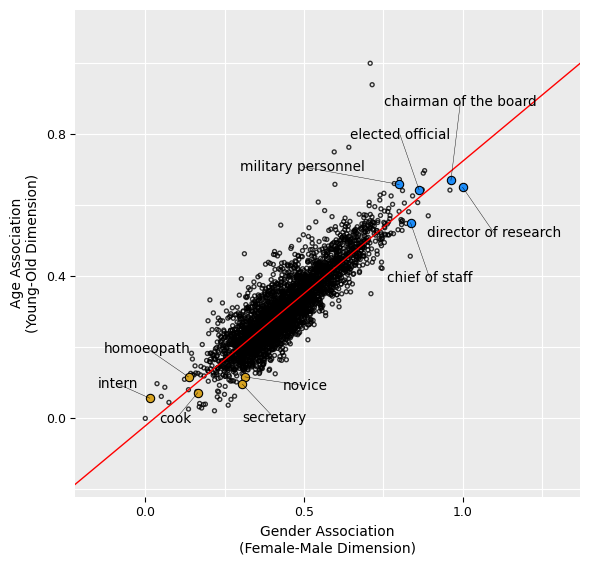

In [9]:
fig, ax = plt.subplots(figsize=(6, 5.75))

#unhighlighted scatter plot
ax.scatter(gpt2_df[gpt2_df['perceived_job_type'] == 'normal']['gender_norm_main'],
           gpt2_df[gpt2_df['perceived_job_type'] == 'normal']['age_norm_main'],
           facecolors='none', edgecolors='black', s=8, alpha=0.8)

#regression line
x_range = np.linspace(-0.25, 1.37, 100)#line x_range
y_range = age_gender_res.predict(pd.DataFrame({'gender_norm_main': x_range}))
ax.plot(x_range, y_range, color='red', linewidth=1)

ax.set_facecolor('#ebebeb')
ax.xaxis.set_major_locator(FixedLocator([0, 0.5, 1.0]))
ax.yaxis.set_major_locator(FixedLocator([0, 0.4, 0.8]))
ax.xaxis.set_minor_locator(FixedLocator([0.25, 0.75, 1.25]))
ax.yaxis.set_minor_locator(FixedLocator([-0.2, 0.2, 0.6, 1.0]))
ax.tick_params(axis='x', labelsize=9, direction='out', bottom=True)
ax.tick_params(axis='y', labelsize=9, direction='out', left=True)
ax.grid(color='white', which='both')
ax.tick_params(axis='both', which='minor', length=0)
ax.set_axisbelow(True)#set gridlines below data

#set plot x and y limits
ax.set_xlim(-0.22, 1.37)
ax.set_ylim(-0.22, 1.15)
ax.set_xlabel('Gender Association\n(Female-Male Dimension)', fontsize=10)
ax.set_ylabel('Age Association\n(Young-Old Dimension)', fontsize=10)

label_offsets = {
    'chairman of the board': (0.03,  0.221),
    'elected official': (-0.06,  0.155),
    'military personnel': (-0.305,  0.05),
    'director of research': (0.1, -0.13),
    'chief of staff': (0.06, -0.155),
    'homoeopath': (-0.13,  0.08),
    'intern': (-0.10,  0.040),
    'novice': ( 0.19, -0.025),
    'cook': (-0.07, -0.075),
    'secretary': ( 0.1, -0.095),
}

colors = {'masculine': '#1d8dfa', 'feminine': '#d6a21f'}

for job_type, color in colors.items():
    #highlighted scatter plot
    subset = gpt2_df[gpt2_df['perceived_job_type'] == job_type]
    ax.scatter(subset['gender_norm_main'], subset['age_norm_main'],
               color=color, linewidth=0.8, edgecolors='black')
    #manual label positioning
    for _, row in subset.iterrows():
        dx, dy = label_offsets[row['social_category']]
        x0, y0 = row['gender_norm_main'], row['age_norm_main']
        x1, y1 = x0 + dx, y0 + dy #label position = data position + label offsets
        #plot line from (x0,y0) to (x1,y1)
        ax.plot([x0, x1], [y0, y1], color='black', lw=0.3)
        ax.text(x1, y1, row['social_category'], fontsize=9.8,
                va='center', ha='center')#center label on (x1,y1) point

#set plot outline invisible
for spine in ax.spines.values():
    spine.set_visible(False)
        
plt.tight_layout()
plt.show()

### 2. Interactive Plot

To create the interactive plot we used Altair to match the provided `age_gender_regression_interactive.html`
file, which uses Vega-Lite's built-in toolbar. More specifically we:
1. created the scatter points with `mark_point()` and used `clip=False` to allow them to render
   outside the plot domain as in the provided file.
2. colored and sized them according to their `perceived_job_type` column value.
3. used `tooltip` to show the points' job name and both axis values formatted to 2 decimal places when the
   mouse hovers over them.
4. added the regression line using `transform_regression()` which fits the data directly and used `mark_line()`
   to render it in the figure.
5. layered the regression line on top of the scatter with `fig + regression_layer ` using Altair's `+`
   operator.

In [10]:
fig = alt.Chart(gpt2_df).mark_point(filled=True, stroke='black', strokeWidth=0.3, opacity=0.7, clip=False).encode(
    x=alt.X('gender_norm_main:Q', scale=alt.Scale(domain=[0, 1]), title=['Gender Association', '(Female-Male Dimension)']),
    y=alt.Y('age_norm_main:Q', scale=alt.Scale(domain=[0, 1]), title=['Age Association', '(Young-Old Dimension)']),
    color=alt.Color('perceived_job_type:N', legend=None, scale=alt.Scale(
        domain=['normal', 'masculine', 'feminine'],
        range=['lightgrey', '#61b1ff', '#e5c062']
    )),
        size=alt.Size('perceived_job_type:N', legend=None, scale=alt.Scale(
        domain=['normal', 'masculine', 'feminine'],
        range=[30,100, 100]
    )),
    tooltip=[alt.Tooltip('social_category:N'),
            alt.Tooltip('gender_norm_main:Q', format='.2f'),
            alt.Tooltip('age_norm_main:Q', format='.2f')
            ]
).properties(width=400, height=400)

final_plot = fig + fig.transform_regression('gender_norm_main', 'age_norm_main').mark_line().encode(color=alt.value('red'), size=alt.value(2))
final_plot.show()

alt.LayerChart(...)

The regression plots show a strong linear relationship between gender association and age association.
This is expected, as the OLS model produced an $R^2 = 0.76$, which corresponds to a Pearson correlation
coefficient of $r = 0.87$ (since $R^2 = r^2$ for simple linear regression with one predictor). This further supports
the paper's case that female-associated occupations tend to be perceived as younger than male-associated ones by
the model.

The points/outliers highlighted by the authors illustrate this well: cook and secretary, traditionally
female-coded occupations, cluster toward the bottom-left of the plot (young and female), while military
personnel and elected official, traditionally associated with older males, appear in the top-right region
of the graph. However, several weaknesses appear in the form of unhighlighted outliers that warrant discussion,
grouped by the nature of their anomaly:

**Counterintuitive placements**  
*Colonel, demagogue, captain* and similar male/older-associated titles appear in the bottom-left (young-female)
region, contradicting intuition.

**Misplaced gender associations**  
*Lad* (0.18, 0.03), *working girl* (0.7, 0.57), *female person* (0.69, 0.57), *daughter* (0.62, 0.41)
and *sister-in-law* (0.6, 0.75) are all misplaced relative to their definitional gender — lad falls in the
female corner, while the rest land in the male half despite being explicitly female terms.

**Gender-mirrored pairs collapsing onto identical positions**  
*Granddaughter* and *grandson* (≈0.4, 0.15), *bride-to-be* (0.40, 0.43) and *groom-to-be* (0.42, 0.47),
*old man* and *old woman* (≈0.88, 0.7), and *widow* (0.06, 0.09) and *widower* (0.16, 0.15) all cluster
together despite being definitionally opposite in gender. The model appears unable to separate gender-mirrored 
pairs, treating shared social context as more salient than gender itself.

**Counterintuitive age associations**  
*Brother-in-law* (0.71, 1.0) is perceived as older than *father-in-law* (0.71, 0.94),
inverting the expected generational order.

**Prefix-driven clustering**  
*Anti-American*, *anti-Catholic* and *non-resistant* (≈0.4, 0.45) cluster together despite having no
meaningful semantic relationship beyond their negative prefix. This suggests the model is partly sensitive
to patterns rather than purely semantic content.

These outliers are not surprising when the model's algorithm is considered. Since GPT-2 Large's 
associations are derived purely from cosine distances between word embeddings in sentence completions,
*the model only learns which words tend to co-occur in similar contexts* in its training data. As such,
definitionally gendered terms get overridden by their contextual associations (e.g. *working girl* due to 
working which is male-associated), gender-mirrored pairs collapse because they appear in identical contexts,
and morphologically similar terms (e.g. *anti-american* and *non-resistant*) cluster due to surface-level
pattern matching.

## Amplification via Google Search

Having established that GPT-2 Large's internal representations encode a strong age-gender bias, researchers
tested whether Google Image search amplifies occupational bias by splitting participants into two groups:

- Treatment group: searched Google Images for occupations, uploaded a result, then labeled the depicted person's
  gender, estimated their age, and rated their hirability.
- Control group: searched for unrelated images (e.g., apples, guitars), then estimated the age of a randomly
  assigned occupation without an image prompt.

The results of the experiment are in files `experiment_control.csv`and `experiment_treatment.csv` which need preprocessing.

### Data Preprocessing: Amplification via Google Search

In [11]:
control_df = pd.read_csv(base_path / "experiment_control.csv")
treat_df = pd.read_csv(base_path / "experiment_treatment.csv")

It is imperative to clarify that the `gender` column in `control_df` signifies which gender the 
control participants thought is most likely to belong to each occupation.

In [12]:
control_df[['category', 'gender']].head(1)

,category,gender
0,aeronauticalengineer,Male


As shown below, some entries in the dataset contain `"Not Sure"` as the gender label. Since the analysis focuses exclusively on the amplification of bias between men and women, these entries will be dropped from the dataset.

In [13]:
print(control_df['gender'].unique())
print(treat_df['gender'].unique())

['Male' 'Not Sure' 'Female']
['Female' 'Male' 'Not Sure']


### Distribution Plot

To see the effects of image search, we create a distribution plot.
The plot shows two distributions, male and female, of the age differences between the age reported by
the participants in the treatment and control groups. The age difference is the *age estimated by each subject 
for each category* in the treatment group minus the *average age `estimated` for the
category* in the control group.  
We will first calculate the mean per category including the `Not Sure` entries seeing that they still
provide information regarding the average perceived age per occupation and then drop it to focus 
exclusively on male vs female age perceptions.

In [14]:
#find mean by category for control group
control_mean = control_df.groupby(['category'])['age'].mean()
#drop 'Not Sure' entries
control_df = control_df[control_df['gender'] != 'Not Sure'].copy()
treat_df = treat_df[treat_df['gender'] != 'Not Sure'].copy()

In [15]:
#create age differences column
exp_treat = treat_df.copy()
exp_treat['age_diff'] = exp_treat['age'] - exp_treat['category'].map(control_mean)

To create the plot, we will use Plotnine, specifically, we visualize the data with a Density Plot, 
constructed as follows:

- The previously computed `age_diff` is mapped to the x-axis, with `fill='gender'` separating the two groups.
- `geom_density` computes and renders the density curves.
- Three vertical lines are added via `geom_vline`, with `xintercept` controlling their positions on the x-axis.
- `scale_fill_manual` assigns custom colors to each gender group.
- `theme_bw()` applies the classic dark-on-light ggplot2 theme.

It should be noted that `xlim(-22, 30)` clips the x-axis, causing Plotnine to raise a `PlotnineWarning` about removed rows. Since this is not a data quality issue the warning can be safely ignored.

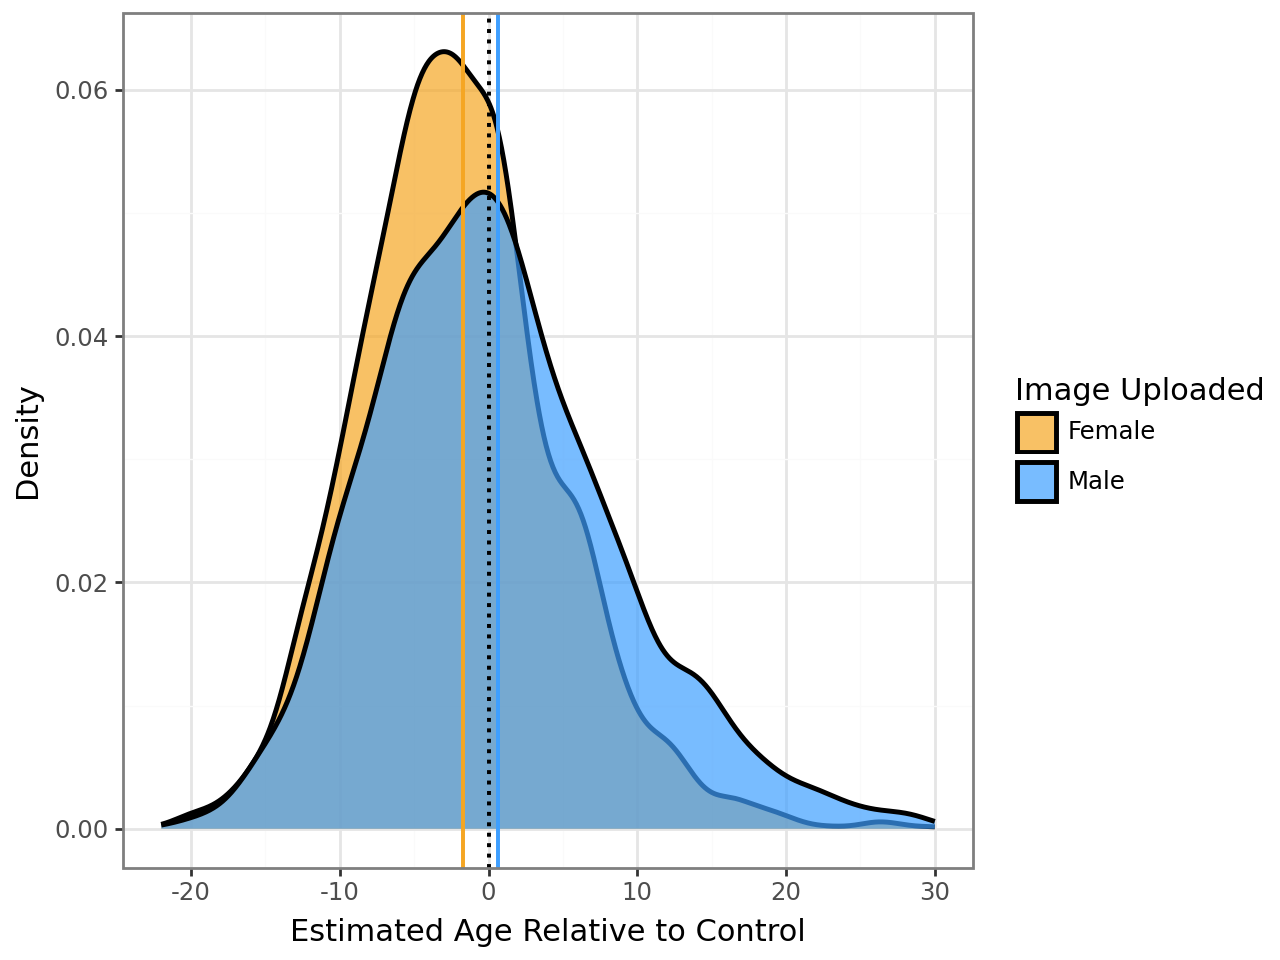

In [16]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", PlotnineWarning)
    dens_plot =(
        ggplot(exp_treat, aes(x='age_diff', fill='gender'))
        + geom_density(alpha=0.7, color='black', size=1)
        + geom_vline(xintercept=exp_treat[exp_treat['gender']=='Male']['age_diff'].mean(), color='#3e9fff', size=0.8)
        + geom_vline(xintercept=exp_treat[exp_treat['gender']=='Female']['age_diff'].mean(), color='#f5a623', size=0.8)
        + geom_vline(xintercept=0, color='#000000', linetype='dotted', size=0.8)
        + scale_fill_manual(values={'Female': '#f5a623', 'Male': '#3e9fff'})
        + xlim(-22, 30)
        + labs(x='Estimated Age Relative to Control', y='Density', fill='Image Uploaded')
        + theme_bw()
    )
    display(dens_plot)

The density plot reveals a striking difference between the two distributions. The female 
curve is narrower and taller, indicating that participants who uploaded a female image
gave consistently lower age estimates than those of the control group. On the other hand,
the male curve is wider and flatter, with a long right tail visible in the plot, reflecting
far greater  variability, meaning that uploading a male image could push age estimates 
anywhere from near-baseline to well above it. As such, it could be said that female images
pull estimates below baseline while male images push them above it, though less uniformly. 
This asymmetry between the two distributions supports the authors' claim that:

> The participants who uploaded an image of a woman estimated the
> average age of an occupation to be 5.46 years younger than those who
> uploaded an image of a man ($t = −19.07$; $p$-value
> $= 2.2 \times 10^{−16}$; Student's t-test), holding occupation
> constant. Moreover, uploading an image of a woman led the participants
> to estimate a significantly lower age for each occupation (by 1.75 years)
> compared with the control participants ($t = −11.32$; 
> $p$-value $= 2.2 \times 10^{−16}$), whereas uploading an
> image of a man led the participants to estimate a significantly
> higher age for each occupation (by 0.64 years) compared with those
> in the control condition ($t = 3.42$; $p$-value $= 0.0006$; Student's 
> two-tailed t-test)

Below are the exact calculations that verify the above. Prior to running the first t-test, 
[Levene's test](https://en.wikipedia.org/wiki/Levene%27s_test) is used to determine whether 
the variances of the two groups — participants who uploaded a female image and those who uploaded 
a male image — are equal.

In [17]:
stat, p = levene(
    exp_treat[exp_treat['gender'] == 'Female']['age'],
    exp_treat[exp_treat['gender'] == 'Male']['age']
)
print(f"Levene's statistic: {round(stat, 2)}")
print(f"p-value: {p:.2e}")

Levene's statistic: 63.89
p-value: 1.64e-15


Looking at the results Levene's statistic = 63.89 and p = 1.64 × 10⁻¹⁵ < 0.05, we conclude that the two variances are 
not equal and as such Welch's t-test, a generalization of Student's t-test, will be chosen over the latter.
The differences between the two are the following:

> Student's t-test assumes that the sample means being compared for two populations are normally distributed, and that the populations have equal
> variances. Welch's t-test is designed for unequal population variances, but the assumption of normality is maintained. Welch's t-test is an
> approximate solution to the Behrens–Fisher problem.
>
> — [Welch's t-test, Wikipedia](https://en.wikipedia.org/wiki/Welch%27s_t-test)

In [18]:
mean_diff = round(exp_treat[exp_treat['gender'] == 'Female']['age'].mean() - 
                  exp_treat[exp_treat['gender'] == 'Male']['age'].mean(), 2)

statistic, pvalue = ttest_ind(
    exp_treat[exp_treat['gender'] == 'Female']['age'],
    exp_treat[exp_treat['gender'] == 'Male']['age'],
    equal_var=False  #False = Welch's and True = Student's
)

print(f"Mean difference when uploading images of women vs men: {mean_diff} years")
print(f"t-statistic: {round(statistic, 2)}")
print(f"p-value: {pvalue:.2e}")

Mean difference when uploading images of women vs men: -5.46 years
t-statistic: -19.07
p-value: 5.24e-78


Continuing with the next two tests, we use `ttest_1samp`, which tests whether the mean of a sample 
differs significantly from a fixed reference value (`popmean`). Here, `popmean=0` represents the 
control group baseline since `age_diff` is defined as the treatment age minus the control mean for 
each occupation, a value of zero means no difference from control.

In [19]:
mean_diff_fem = round(exp_treat[exp_treat['gender'] == 'Female']['age_diff'].mean(), 2)
mean_diff_male = round(exp_treat[exp_treat['gender'] == 'Male']['age_diff'].mean(), 2)

statistic_fem, pvalue_fem = ttest_1samp(
    exp_treat[exp_treat['gender'] == 'Female']['age_diff'],
    popmean=0
)
statistic_male, pvalue_male = ttest_1samp(
    exp_treat[exp_treat['gender'] == 'Male']['age_diff'],
    popmean=0
)

print(f"Mean age difference when uploading images of women vs control: {mean_diff_fem} years")
print(f"t-statistic: {round(statistic_fem, 2)}")
print(f"p-value: {pvalue_fem:.2e}")

print()

print(f"Mean age difference when uploading images of men vs control: {mean_diff_male} years")
print(f"t-statistic: {round(statistic_male, 2)}")
print(f"p-value: {pvalue_male:.2e}")

Mean age difference when uploading images of women vs control: -1.75 years
t-statistic: -11.32
p-value: 4.82e-29

Mean age difference when uploading images of men vs control: 0.64 years
t-statistic: 3.42
p-value: 6.37e-04


The tests confirm that simply associating an occupation with a woman's image causes
people to perceive that role as younger and, by extension, less senior and experienced.
The 5.46-year gap between the age estimations of the treatment participants who uploaded
female versus male images may suggest that gender plays an instrumental role in shaping
occupational age perception, and moreover that Google Images itself showcases systematically
different ages across genders within the same occupation — which would indeed amplify already
existing biases rather than create them from scratch.  

Furthermore, the asymmetry between the age estimates of the male and female treatment groups
relative to the control baseline reinforces this interpretation. While exposure to a female
image led participants to estimate occupational ages 1.75 years below the baseline, exposure
to a male image increased estimates by only 0.64 years. This imbalance means that the
control condition, which simulates the baseline societal perceptions, is closer to the
male associated age. This indicates that Google Images' algorithm makes women appear younger 
than it makes men appear older and as such reinforces existing age–gender biases rather than
simply reflecting them, and disproportionately affects perceptions of women.

## Investigate the Amplification

Having established that Google Image search significantly amplifies age-related gender bias, we now 
investigate the structure of this amplification more rigorously. We take the treatment and control 
together as one dataset and run a regression with `age` as the dependent variable and the following 
independent variables:

* `condition * gender`, with gender as categorical with Treatment
  coding and `Male` as the reference level

* `category`

* `subj`

  
To create the combined dataset from `control_df` and `treat_df`, we exclude the `ideal_age` column
from `control_df`, which -as seen below- is absent from `treat_df` and not needed for
the remainder of the assignment.

In [20]:
print(control_df.columns)
print(treat_df.columns)

Index(['category', 'subj', 'age', 'ideal_age', 'condition', 'gender'], dtype='object')
Index(['subj', 'category', 'age', 'gender', 'condition'], dtype='object')


In [21]:
control_treat_df = pd.concat([
    control_df.drop(columns='ideal_age'), 
    treat_df
], ignore_index=True)
#control part in the beginning
control_treat_df.head(3)

,category,subj,age,condition,gender
0,aeronauticalengineer,55595b70fdf99b387ae30d2b,50.27,Control,Male
1,aeronauticalengineer,5843241166ef8c00018955fd,39.95,Control,Male
2,aeronauticalengineer,59baa339ab8d830001fe56f5,40.08,Control,Male


In [22]:
#image/treatment part in the end
control_treat_df.tail(3)

,category,subj,age,condition,gender
8511,schoolteacher,65975d5b8d7a9d142ec61668,23.19,Image,Female
8512,screenactor,65975d5b8d7a9d142ec61668,30.16,Image,Male
8513,socialworker,65975d5b8d7a9d142ec61668,26.01,Image,Female


In [23]:
reference = 'Male'
control_treat_mod = smf.ols(
    f"age ~ C(condition, Treatment(reference='Control')) * C(gender, Treatment(reference='{reference}')) + category + subj",
    data=control_treat_df
)
control_treat_res = control_treat_mod.fit()
control_treat_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    age   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     22.30
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:48:28   Log-Likelihood:                -28066.
No. Observations:                8514   AIC:                         5.715e+04
Df Residuals:                    8005   BIC:                         6.074e+04
Df Model:                         508                                         
Covariance Type:            nonrobust                                         
==========================================================================================================================================================================
                                                                                                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                                 44.1459      1.524     28.963      0.000      41.158      47.134
C(condition, Treatment(reference='Control'))[T.Image]                                                     -4.7819      1.447     -3.305      0.001      -7.618      -1.946
C(gender, Treatment(reference='Male'))[T.Female]                                                          -2.1919      0.288     -7.614      0.000      -2.756      -1.628
category[T.appliedscientist]                                                                              -0.1997      0.772     -0.259      0.796      -1.713       1.314
category[T.artstudent]                                                                                   -15.9195      0.769    -20.691      0.000     -17.428     -14.411
category[T.artteacher]                                                                                    -1.5589      0.760     -2.050      0.040      -3.049      -0.068
category[T.astronaut]                                                                                      0.8480      0.756      1.121      0.262      -0.635       2.331
category[T.astrophysicist]                                                                                 5.5395      0.746      7.422      0.000       4.076       7.002
category[T.automotiveengineer]                                                                            -3.0039      0.741     -4.056      0.000      -4.456      -1.552
category[T.bookkeeper]                                                                                    -0.1153      0.754     -0.153      0.878      -1.593       1.362
category[T.cardiologist]                                                                                   7.2159      0.752      9.600      0.000       5.743       8.689
category[T.chiefexecutiveofficer]                                                                         10.7181      0.744     14.401      0.000       9.259      12.177
category[T.chiropractor]                                                                                   0.8699      0.749      1.161      0.246      -0.599       2.338
category[T.clarinetist]                                                                                   -3.6484      0.738     -4.943      0.000      -5.095      -2.202
category[T.climatologist]                                                                                  1.0234      0.759      1.348      0.178      -0.465       2.511
categ

The model's coefficient table, in the second, third and last line, provides three valuable insights:

1. Image condition age estimates are 4.78 years lower on average than those of control 
   conditions (95% CI = [-7.618, -1.946], p < 0.001), regardless of whether the gender is 
   male or female. 
2. Female images lower age estimates by 2.19 years compared to male images 
   (95% CI = [-2.756, -1.628], p < 0.001).
3. The effect of uploading a female image in the image condition lowers age estimates by an additional 0.85 years
    compared to a control participant who believed the relevant field to be more male-associated, above and
    beyond the main effects of condition and gender. (95% CI = [-1.468, -0.231], p = 0.007).
   
These results are consistent with the paper's finding that not only do image condition
participants estimate younger ages overall, but that the downward effect is significantly stronger when
the uploaded image depicts a woman.
   
We continue by running the second regression for `age` with only `category` and
`subj` as the independent variables. We use this model to predict the age for the combined  treatment and
control dataset.

In [24]:
control_treat_mod = smf.ols("age ~ category + subj", data=control_treat_df)
control_treat_res = control_treat_mod.fit()
control_treat_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    age   R-squared:                       0.576
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     21.53
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:48:30   Log-Likelihood:                -28162.
No. Observations:                8514   AIC:                         5.734e+04
Df Residuals:                    8007   BIC:                         6.091e+04
Df Model:                         506                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            44.2252      1.539     28.736      0.000      41.208      47.242
category[T.appliedscientist]         -1.5052      0.775     -1.943      0.052      -3.024       0.013
category[T.artstudent]              -17.2907      0.768    -22.512      0.000     -18.796     -15.785
category[T.artteacher]               -3.7093      0.749     -4.950      0.000      -5.178      -2.240
category[T.astronaut]                 0.6670      0.765      0.872      0.383      -0.832       2.166
category[T.astrophysicist]            5.3222      0.755      7.053      0.000       3.843       6.801
category[T.automotiveengineer]       -2.7564      0.749     -3.681      0.000      -4.224      -1.289
category[T.bookkeeper]               -1.9309      0.746     -2.588      0.010      -3.393      -0.468
category[T.cardiologist]              6.8756      0.760      9.050      0.000       5.386       8.365
category[T.chiefexecutiveofficer]    10.1332      0.751     13.488      0.000       8.660      11.606
category[T.chiropractor]              0.5772      0.757      0.762      0.446      -0.907       2.062
category[T.clarinetist]              -4.4974      0.740     -6.075      0.000      -5.949      -3.046
category[T.climatologist]             0.5311      0.766      0.693      0.488      -0.971       2.034
category[T.computerexpert]           -5.6404      0.746     -7.561      0.000      -7.103      -4.178
category[T.cosmeticsurgeon]           4.3045      0.760      5.665      0.000       2.815       5.794
category[T.dietician]                -4.6026      0.744     -6.187      0.000      -6.061      -3.144
category[T.dressmaker]               -1.2897      0.726     -1.776      0.076      -2.713       0.134
category[T.editorinchief]             6.8869      0.764      9.012      0.000       5.389       8.385
category[T.educator]                 -3.7278      0.774     -4.819      0.000      -5.244      -2.211
category[T.englishprofessor]          7.2836      0.778      9.365      0.000       5.759       8.808
category[T.englishteacher]           -3.3781      0.734     -4.601      0.000      -4.817      -1.939
category[T.fashiondesigner]          -5.7644      0.743     -7.754      0.000      -7.222      -4.307
category[T.fashionmodel]            -14.9981      0.759    -19.768      0.000     -16.485     -13.511
category[T.financialanalyst]         -0.8069      0.746     -1.081      0.280      -2.270       0.656
category[T.geneticist]                0.9448      0.788      1.199      0.231      -0.600       2.490
category[T.graphicdesigner]          -8.7966      0.775    -11.355      0.000     -10.315      -7.278
category[T.harpist]                  -4.1142      0.758     -5.425      0.000      -5.601      -2.628
category[T.hygienist]  

The model captures how much of the variance in perceived age is explained  by the category and the individual 
subjects rating it. The results of the model indicate that they explain  $R^2 = 0.576$ (57.6%) of the variance 
in age. The value drops to $Adj. R^2 = 0.550$ (55%) once penalised for the large number of predictors, 
reflecting that some category and subject levels contribute little to the model. Additionally, the model's 
F-statistic ($F = 21.53$, $p < .001$) confirms its overall significance.  

As the model summary is too large to interpret directly, we visualize its predictions and 
residuals to gain an intuitive understanding of the results. The latter are computed by subtracting the 
model's predicted ages from the perceived ages across both conditions, Residuals close to zero indicate 
that category and subject alone explain most of the variance in a condition's estimates, while 
large residuals suggest that additional factors — namely, the gender of the uploaded image 
and the experimental condition — are driving the age estimates.

In [25]:
control_treat_df['age_pred'] = control_treat_res.predict(control_treat_df)
control_treat_df['resid'] = control_treat_df['age'] - control_treat_df['age_pred']

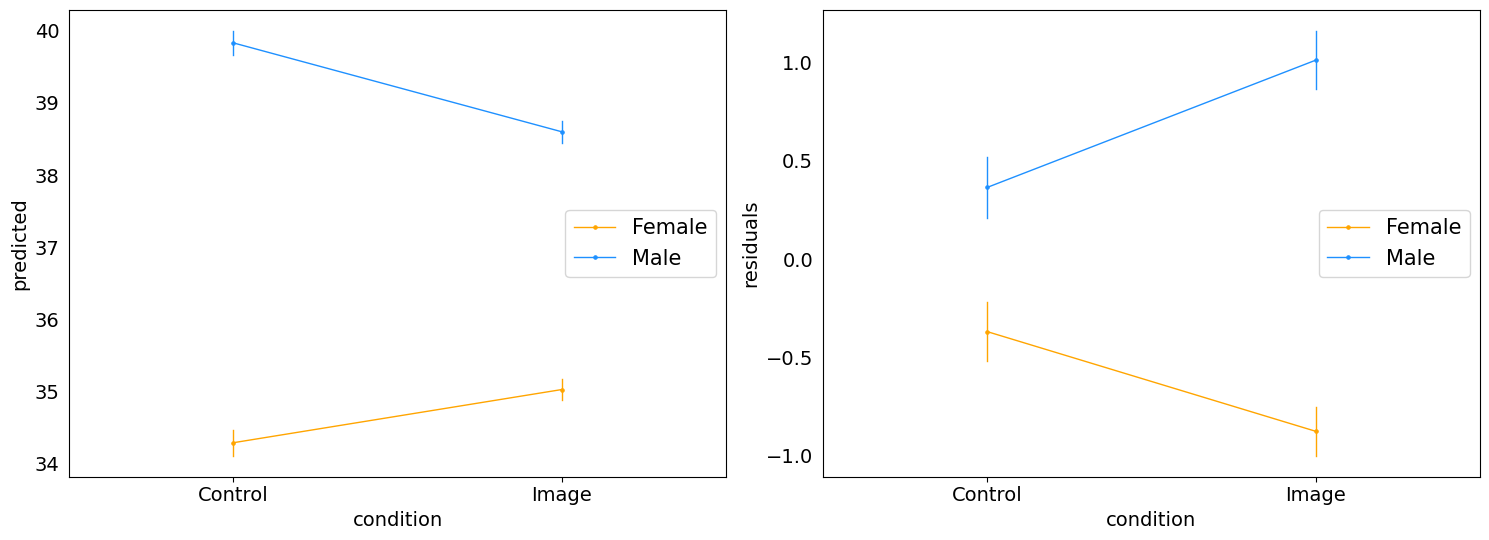

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

plot_configs = [
    {'y': 'age_pred', 'ylabel': 'predicted'},
    {'y': 'resid', 'ylabel': 'residuals'}
]

for ax, config in zip(axes, plot_configs):
    sns.pointplot(
        ax=ax,
        data=control_treat_df,
        x='condition',
        y=config['y'],
        hue='gender',
        hue_order=['Female', 'Male'],
        palette={'Female': '#ffa500', 'Male': '#1e90ff'},
        linewidth=1,
        errorbar='se'#std error (not default 95% CI) to match assignment sheet
    )
    
    ax.set_xlabel('condition')
    ax.set_ylabel(config['ylabel'])
    ax.tick_params(left=False, labelsize=14)
    ax.yaxis.label.set_size(14)
    ax.xaxis.label.set_size(14)
    ax.legend(fontsize=15, loc='center right')

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

- The first plot shows that the model predicts more polarised age estimates for the control group 
  than for the image condition, where male and female predictions are closer together. 
- The second plot shows that the residuals of the image condition are further from zero 
  than those of the control group, negative for female images and positive for male ones. This means
  that the model is more precise for the control condition than the image condition and systematically
  underpredicts age estimates regarding women and overpredicts regarding men.

Taken together, this suggests that age perception is more consistent when based purely on the perceiver and 
the occupation, whereas images introduce additional factors that drive estimates in directions the model 
cannot account for. The most prominent such factors are likely whether a picture was shown and by extension
the gender of the person depicted in it, which significantly drives age perception in a directional way,
something that does not occur in the control condition. As such, it is once again clear that Google Images
affects gender/age occupation perceptions.

## ANOVA ANALYSIS

Finally, to understand whether condition and gender *do in fact explain the unexplained variance* from the
above OLS, we run two ANOVA models.

The first has only `condition * gender` as independent variables, while the second adds `category` and `subj`, 
revealing how much of the variance attributed to condition and gender is absorbed once occupation and subject
are controlled for.   

To handle the categorical variables, we apply Sum encoding (also called deviation coding) via `statsmodels' C()`.

In [27]:
anova_1_mod = smf.ols("age ~ C(condition, Sum) * C(gender, Sum)", data=control_treat_df)
anova_1_res = anova_1_mod.fit()
anova_1_table = sm.stats.anova_lm(anova_1_res)
anova_1_table

,df,sum_sq,mean_sq,F,PR(>F)
"C(condition, Sum)",1.0,320.161665,320.161665,3.379631,6.604166e-02
"C(gender, Sum)",1.0,71856.913990,71856.913990,758.522619,5.017108e-160
"C(condition, Sum):C(gender, Sum)",1.0,347.367889,347.367889,3.666820,5.553946e-02
Residual,8510.0,806175.481608,94.732724,NaN,NaN


The above table shows that when looking only at condition and gender:
1. Differences between conditions are not statistically significant ($p=0.066 > \alpha=0.05$).
2. Gender has a strong effect ($F=758.52$) and is statistically significant ($p<0.05$).
3. The interaction between the two factors is not statistically significant ($p=0.055 > \alpha=0.05$).

This suggests that in the absence of category and subject, the condition's effect is undetectable while
the gender's effect is strong enough to be detectable.

In [28]:
anova_2_mod = smf.ols("age ~ C(condition, Sum) * C(gender, Sum) + category + subj", data=control_treat_df)
anova_2_res = anova_2_mod.fit()
anova_2_table = sm.stats.anova_lm(anova_2_res)
anova_2_table

,df,sum_sq,mean_sq,F,PR(>F)
"C(condition, Sum)",1.0,320.161665,320.161665,7.044641,0.007966
"C(gender, Sum)",1.0,71856.913990,71856.913990,1581.095506,0.000000
category,53.0,242449.980996,4574.527943,100.655110,0.000000
subj,453.0,199942.456107,441.374075,9.711725,0.000000
"C(condition, Sum):C(gender, Sum)",1.0,327.981675,327.981675,7.216708,0.007238
Residual,8005.0,363807.622227,45.447548,NaN,NaN


The addition of category and subject to the model gives new information:

1. Condition is now statistically significant ($F=7.04$, $p=0.008 < \alpha=0.05$), meaning that
   once occupation and subject are controlled for, the experimental condition does have an actual effect.
2. Gender remains strongly significant ($F=1581.10$, $p<0.05$) and its effect has grown, confirming
   that the gender of the depicted image is a driver of age estimates.
3. Category ($F=100.66$, $p<0.05$) and subject ($F=9.71$, $p<0.05$) are both highly significant,
   meaning which occupation is being rated and who is rating it explain a large portion of the variance.
4. The interaction between condition and gender is now also significant ($F=7.22$, $p=0.007 < \alpha=0.05$),
   meaning the effect of image gender on age estimates differs significantly between the image and control
   conditions. This suggests that gender influences age perception differently depending on whether
   participants saw an actual photograph or not.
5. The `residual sum of squares` dropped from 806175 to 363807 when adding category and subject, meaning that their
   addition halved the unexplained variance, making the effects of condition and gender detectable.

The difference between the models shows that condition and gender drive age estimates, but the condition's effect
was obscured in the first model by the large uncontrolled variance attributable to occupation and individual subject
differences. The second model confirms that the condition and gender effects observed in the plots are actually 
significant and not noise introduced by uncontrolled factors.

# CONCLUSION

The results paint a concerning picture of how biases propagate through digital tools that are
indispensable for modern access to information. What is particularly concerning is the "vicious
cycle" this creates. First, existing societal biases are absorbed by language models trained on
human-generated text that is subject to biases, while simultaneously surfacing and being amplified
by image search algorithms. They are then subsequently internalised by people who use them, who in
turn, go on to reproduce those biases in their judgments and behaviour, feeding them back into the
data these systems learn from. The consequences of this sequence are societal: for example, women
assumed as less experienced than men by AI used to grade CVs face an immediate disadvantage, 
amplifying the "glass ceiling" phenomenon.  

The common denominator lies in the algorithms themselves, which are seemingly technical tools whose societal
consequences are often underappreciated. This gap is not solely due to developers' STEM-focused training,
but also reflects broader factors such as limited interdisciplinary input and biased training data.
This is not without precedent. The current situation resembles the invention of the printing press by
Johannes Gutenberg in the 1440s: a technical innovation, created by a goldsmith, aimed at reproducing
text more efficiently. Yet its consequences were massive and largely unforeseen by its creator. It was
people from the humanities who stepped in to interpret and assess its impact. The Italian humanist Niccolò
Perotti, for instance, was so alarmed by the errors spreading through printed editions, that he wrote to
the Pope calling for a board of learned correctors to scrutinise every text before publication 
[(Wikipedia, 2024)](https://en.wikipedia.org/wiki/Niccol%C3%B2_Perotti). This is described as the first call
for press censorship, and a remarkably early recognition that a technical tool required humanistic oversight.

This parallel underscores the recurring pattern of technological innovation often outpacing society's
ability to anticipate and counter its consequences. Similar dynamics can be observed in the cases of the
steam engine and television. Just as humanists played a crucial role in critically assessing the societal
disruptions brought about by the printing press, today’s algorithmic systems demand comparable scrutiny.
Without meaningful interdisciplinary oversight and adequate public awareness, these technologies risk 
shaping knowledge, perception, and inequality in ways that remain insufficiently examined and difficult to
mitigate.